In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
ELLIPSE_ROOT = ANALYSIS_ROOT / 'ellipse_tilt_analysis'
for path in (ANALYSIS_ROOT, CASE_ROOT, FLOW_ROOT, ELLIPSE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
import ellipse_tilt_tools as et

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
ELLIPSE_FRAC = 1.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_pv_gradient_terms(
    df_eddies,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
)
df_eddies = tilt.add_region_labels(df_eddies, grid)

# Surface ellipse geometry and axial tilt alignment (0° parallel, 90° perpendicular).
df_eddies = et.ellipse_geometry(df_eddies)
df_eddies['TiltMajorAlignmentDeg'] = np.abs(
    et.axial_difference(df_eddies.TiltDir, df_eddies.MajorBearing)
)

# Primary environmental shear used in the background-flow analysis:
# centred seasonal climatology, surface minus the 200–500 m layer mean.
background = load_background_cache(BackgroundConfig()).drop(
    columns=['ic', 'jc'], errors='ignore'
)
needed = {'clim_surface_east_ms', 'clim_surface_north_ms',
          'clim_200_east_ms', 'clim_200_north_ms',
          'clim_500_east_ms', 'clim_500_north_ms'}
missing = needed - set(background.columns)
if missing:
    raise RuntimeError(f'Background cache is missing {sorted(missing)}')
df_eddies = df_eddies.merge(
    background[['Eddy', 'Day', *sorted(needed)]],
    on=['Eddy', 'Day'], how='left', validate='one_to_one'
)
for component in ('east', 'north'):
    deep = (500 * df_eddies[f'clim_500_{component}_ms']
            - 200 * df_eddies[f'clim_200_{component}_ms']) / 300
    df_eddies[f'clim_upper_minus_deep_{component}_ms'] = (
        df_eddies[f'clim_200_{component}_ms'] - deep
    )
SHEAR_E = 'clim_upper_minus_deep_east_ms'
SHEAR_N = 'clim_upper_minus_deep_north_ms'

In [3]:
df_eddies.columns


Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'h', 'f', 'beta', 'dhdx', 'dhdy',
       'zeta_mean', 'abs_vort', 'PV', 'PV_footprint_n',
       'PV_weight_effective_n', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_plan_mean_local_mag', 'PV_grad_plan_rms_local_mag',
       'PV_grad_plan_p90_local_mag', 'PV_grad_plan_coherence',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_topo_mean_local_mag',
       'PV_grad_topo_rms_local_mag', 'PV_grad_topo_p90_local_mag',
       'PV_grad_topo_coherence', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_mean_local_mag', 'PV_grad_rms_local_mag',
       'PV_grad_p90_local_mag', 'PV_grad_coherence', 'PV_grad_eddy_x',
       'PV_grad_eddy_y', 'PV_grad_eddy_mean_local_mag',
       'PV_grad_eddy_rms_local_mag', 'PV_grad_eddy_p90_local_mag',
       'PV_grad_eddy_coherence', 'PV_grad_full_x', 'PV_grad_full_y',
   

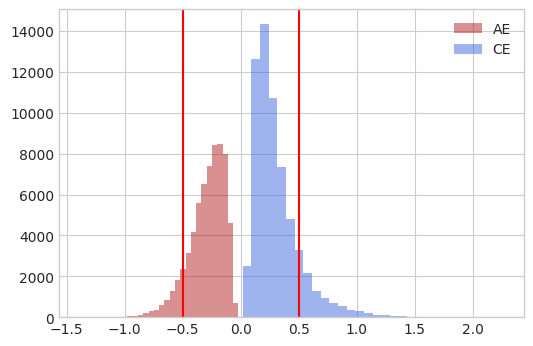

In [42]:
df = df_eddies.copy()
fig,ax=plt.subplots(figsize=(6,4))
for cyc,c in [('AE','firebrick'),('CE','royalblue')]:
    df.loc[df.Cyc.eq(cyc),'Ro'].hist(ax=ax,bins=30,alpha=.5,color=c,label=cyc)
ax.legend()
ax.axvline(.5, color='r'); ax.axvline(-.5, color='r')

Low Ro
AE mean tilt dir -8, tilt dis 26 km
CE mean tilt dir -134, tilt dis 17 km


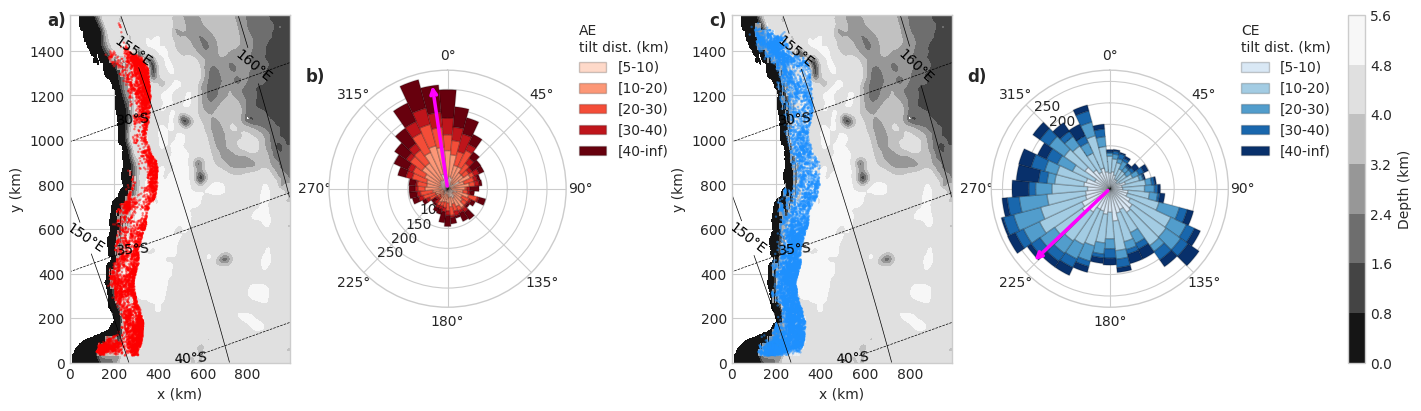

High Ro
AE mean tilt dir -27, tilt dis 20 km
CE mean tilt dir -54, tilt dis 15 km


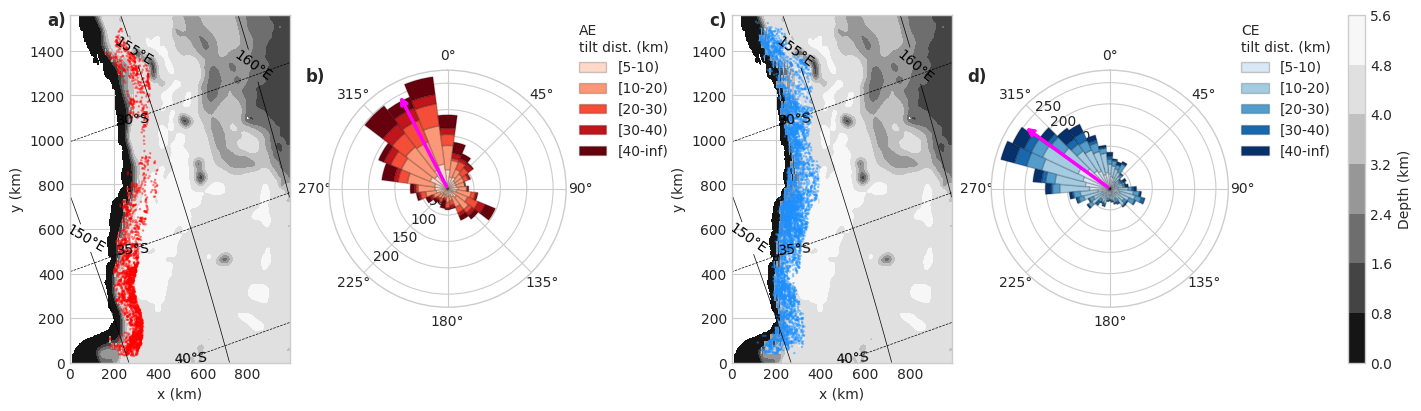

In [33]:
LAT_THRESH = 35
for k, title in enumerate(['Low Ro', 'High Ro']):
    if k==0:
        df = df_eddies[(df_eddies.Ro.abs()<.5)&(df_eddies.Region.isin(['S1','S2']))].copy()
    else:
        df = df_eddies[(df_eddies.Ro.abs()>=.5)&(df_eddies.Region.isin(['S1','S2']))].copy()
    print(title)
    fig, axs = plot_tilt_summary(df)

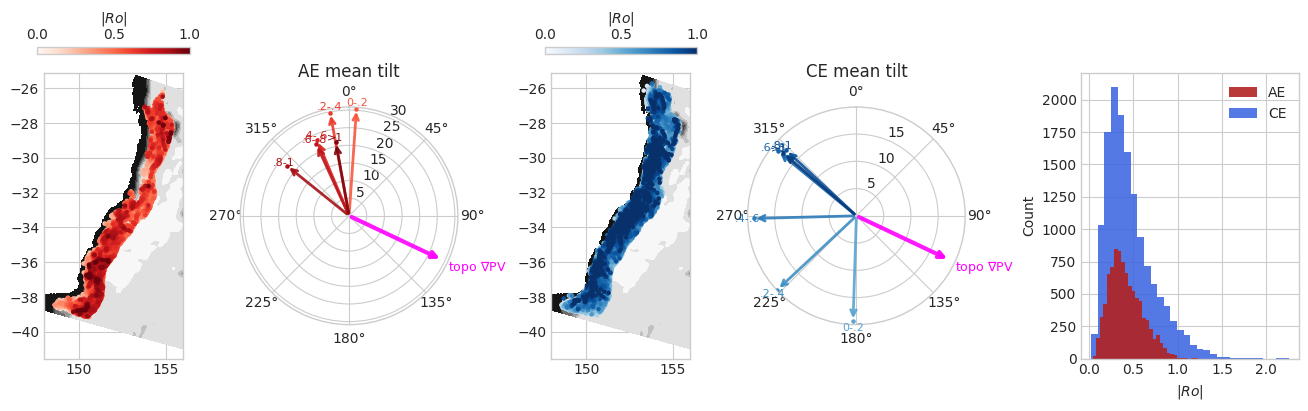

In [143]:
ro_bins=[0,.2,.4,.6,.8,1,np.inf]
labels=['0-.2','.2-.4','.4-.6','.6-.8','.8-1','>1']
vectors={'AE':{'theta':[],'r':[]},'CE':{'theta':[],'r':[]}}

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    d=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['S1','S2']))&(df_eddies.TiltDis>=5)].copy()
    for cyc in ['AE','CE']:
        sub=d[d.Cyc.eq(cyc)].dropna(subset=['TiltDir','TiltDis'])
        theta=np.deg2rad(sub.TiltDir)
        vectors[cyc]['theta'].append(np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi))
        vectors[cyc]['r'].append(sub.TiltDis.mean())

topo=df_eddies[df_eddies.Region.isin(['S1','S2'])].dropna(subset=['PV_grad_topo_x','PV_grad_topo_y'])
topo_theta=np.arctan2(topo.PV_grad_topo_x.mean(),topo.PV_grad_topo_y.mean())%(2*np.pi)

fig=plt.figure(figsize=(13,4),constrained_layout=True)
gs=fig.add_gridspec(1,5,width_ratios=[.7,1,.7,1,1])
axs=[fig.add_subplot(gs[0]),fig.add_subplot(gs[1],projection='polar'),
     fig.add_subplot(gs[2]),fig.add_subplot(gs[3],projection='polar'),fig.add_subplot(gs[4])]

for i,(cyc,cmap) in enumerate(zip(['AE','CE'],['Reds','Blues'])):
    ax,axp=axs[2*i],axs[2*i+1]

    bath=ax.contourf(grid.lon_rho,grid.lat_rho,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    d=df_eddies[df_eddies.Region.isin(['S1','S2'])&df_eddies.Cyc.eq(cyc)].copy()
    d=d.assign(Ro_abs=d.Ro.abs()).sort_values('Ro_abs')
    sc=ax.scatter(d.lon,d.lat,c=d.Ro_abs,cmap=cmap,s=5,vmin=0,vmax=1)
    fig.colorbar(sc,ax=ax,orientation='horizontal',location='top',pad=.05,label=r'$|Ro|$')
    ax.set_aspect('equal',adjustable='box'); ax.set_xlim(148,156)

    theta=np.array(vectors[cyc]['theta']); r=np.array(vectors[cyc]['r'])
    colors=getattr(plt.cm,cmap)(np.linspace(.55,.95,len(labels)))
    axp.set_theta_zero_location('N'); axp.set_theta_direction(-1)
    for th,rr,label,color in zip(theta,r,labels,colors):
        axp.annotate('',xy=(th,rr),xytext=(0,0),arrowprops=dict(arrowstyle='->',color=color,lw=2,alpha=.9))
        axp.scatter(th,rr,color=color,s=5,zorder=3)
        axp.text(th,rr*1.06,label,ha='center',va='center',fontsize=8,color=color)

    rmax=axp.get_ylim()[1]
    axp.annotate('',xy=(topo_theta,.95*rmax),xytext=(topo_theta,0),
                 arrowprops=dict(arrowstyle='->',color='magenta',lw=3,alpha=.9))
    axp.text(topo_theta,1.3*rmax,r'topo $\nabla$PV',color='magenta',ha='center',va='bottom',fontsize=9)
    axp.set_title(f'{cyc} mean tilt')

# Ro histogram
df=df_eddies[df_eddies.Region.isin(['S1','S2'])].copy()
df['Ro_abs']=df.Ro.abs()
ax=axs[4]
zorder = 2
for cyc,c in [('AE','firebrick'), ('CE','royalblue')]:
    df.loc[df.Cyc.eq(cyc),'Ro_abs'].hist(ax=ax,bins=30,alpha=.9,color=c,label=cyc, zorder=zorder)
    zorder -= 1
# ax.axvline(.5,color='r',ls='--',lw=1.5)
ax.set(xlabel=r'$|Ro|$',ylabel='Count')
ax.legend(frameon=False)

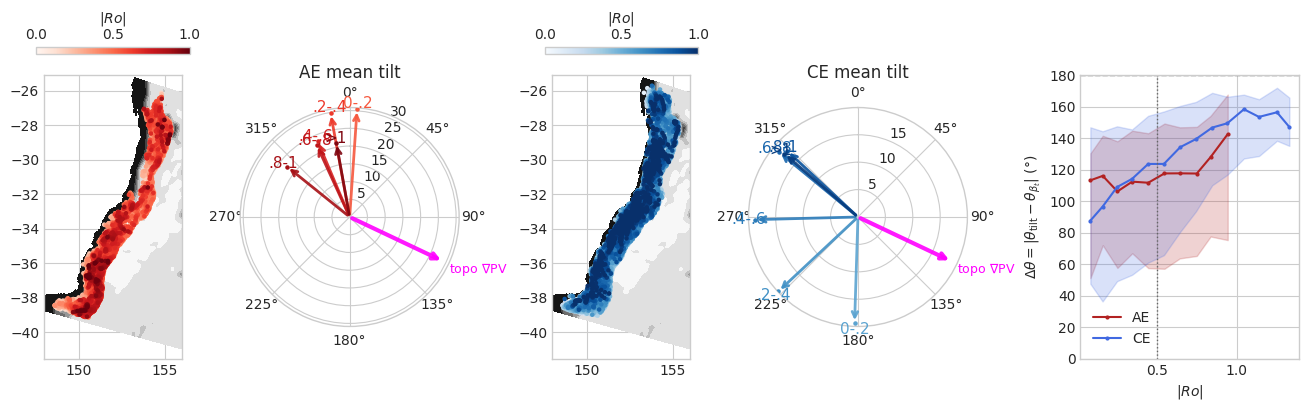

In [205]:
ro_bins=[0,.2,.4,.6,.8,1,np.inf]
labels=['0-.2','.2-.4','.4-.6','.6-.8','.8-1','>1']
vectors={'AE':{'theta':[],'r':[]},'CE':{'theta':[],'r':[]}}

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    d=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['S1','S2']))&(df_eddies.TiltDis>=5)].copy()
    for cyc in ['AE','CE']:
        sub=d[d.Cyc.eq(cyc)].dropna(subset=['TiltDir','TiltDis'])
        theta=np.deg2rad(sub.TiltDir)
        vectors[cyc]['theta'].append(np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi))
        vectors[cyc]['r'].append(sub.TiltDis.mean())

topo=df_eddies[df_eddies.Region.isin(['S1','S2'])].dropna(subset=['PV_grad_topo_x','PV_grad_topo_y'])
topo_theta=np.arctan2(topo.PV_grad_topo_x.mean(),topo.PV_grad_topo_y.mean())%(2*np.pi)

fig=plt.figure(figsize=(13,4),constrained_layout=True)
gs=fig.add_gridspec(1,5,width_ratios=[.7,1,.7,1,1])
axs=[fig.add_subplot(gs[0]),fig.add_subplot(gs[1],projection='polar'),
     fig.add_subplot(gs[2]),fig.add_subplot(gs[3],projection='polar'),fig.add_subplot(gs[4])]

for i,(cyc,cmap) in enumerate(zip(['AE','CE'],['Reds','Blues'])):
    ax,axp=axs[2*i],axs[2*i+1]

    bath=ax.contourf(grid.lon_rho,grid.lat_rho,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    d=df_eddies[df_eddies.Region.isin(['S1','S2'])&df_eddies.Cyc.eq(cyc)].copy()
    d=d.assign(Ro_abs=d.Ro.abs()).sort_values('Ro_abs')
    sc=ax.scatter(d.lon,d.lat,c=d.Ro_abs,cmap=cmap,s=5,vmin=0,vmax=1)
    fig.colorbar(sc,ax=ax,orientation='horizontal',location='top',pad=.05,label=r'$|Ro|$')
    ax.set_aspect('equal',adjustable='box'); ax.set_xlim(148,156)

    theta=np.array(vectors[cyc]['theta']); r=np.array(vectors[cyc]['r'])
    colors=getattr(plt.cm,cmap)(np.linspace(.55,.95,len(labels)))
    axp.set_theta_zero_location('N'); axp.set_theta_direction(-1)
    for th,rr,label,color in zip(theta,r,labels,colors):
        axp.annotate('',xy=(th,rr),xytext=(0,0),arrowprops=dict(arrowstyle='->',color=color,lw=2,alpha=.9))
        axp.scatter(th,rr,color=color,s=5,zorder=3)
        axp.text(th,rr*1.06,label,ha='center',va='center',fontsize=11,color=color)

    rmax=axp.get_ylim()[1]
    axp.annotate('',xy=(topo_theta,.95*rmax),xytext=(topo_theta,0),
                 arrowprops=dict(arrowstyle='->',color='magenta',lw=3,alpha=.9))
    axp.text(topo_theta,1.3*rmax,r'topo $\nabla$PV',color='magenta',ha='center',va='bottom',fontsize=9)
    axp.set_title(f'{cyc} mean tilt')

# Ro vs alignment
ax=axs[4]
for cyc,clr in [('AE','firebrick'),('CE','royalblue')]:
    df=df_eddies[(df_eddies.Cyc.eq(cyc))&(df_eddies.Region.isin(['S1','S2']))&(df_eddies.TiltDis>=5)].copy()
    df['Ro_abs']=df.Ro.abs()
    bins=np.arange(0,df.Ro_abs.max()+.1,.1)
    df['Ro_bin']=pd.cut(df.Ro_abs,bins)
    stats=df.groupby('Ro_bin',observed=True).agg(
        Ro=('Ro_abs','median'),dtheta=('dtheta_PV_grad_topo','median'),
        q25=('dtheta_PV_grad_topo',lambda x:x.quantile(.25)),
        q75=('dtheta_PV_grad_topo',lambda x:x.quantile(.75)),
        n=('dtheta_PV_grad_topo','count')).query('n>=20')
    ax.plot(stats.Ro,stats.dtheta,'o-',color=clr,label=cyc, markersize=2)
    ax.fill_between(stats.Ro,stats.q25,stats.q75,color=clr,alpha=.2)

ax.axhline(180,color='.4',ls='--',lw=1)
ax.axvline(.5,color='.4',ls=':',lw=1)
ax.set(xlabel=r'$|Ro|$',ylabel=r'$\Delta\theta=|\theta_{\text{tilt}}-\theta_{\beta_t}|$ (°)',ylim=(0,180))
ax.legend(frameon=False)

<Axes: xlabel='Ro_abs'>

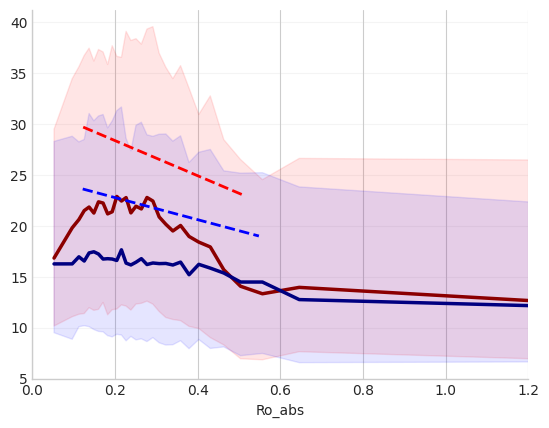

In [165]:
fig, ax = plt.subplots()
df_eddies['Ro_abs'] = df_eddies.Ro.abs()
tilt.binned_tilt_panel(ax, df_eddies, "Ro_abs", "Ro_abs", xlim=(0,1.2), linfit=True)

#### off shelf

Ro 0.0–0.2: n=40480
AE mean tilt dir 22, tilt dis 27 km
CE mean tilt dir 141, tilt dis 23 km


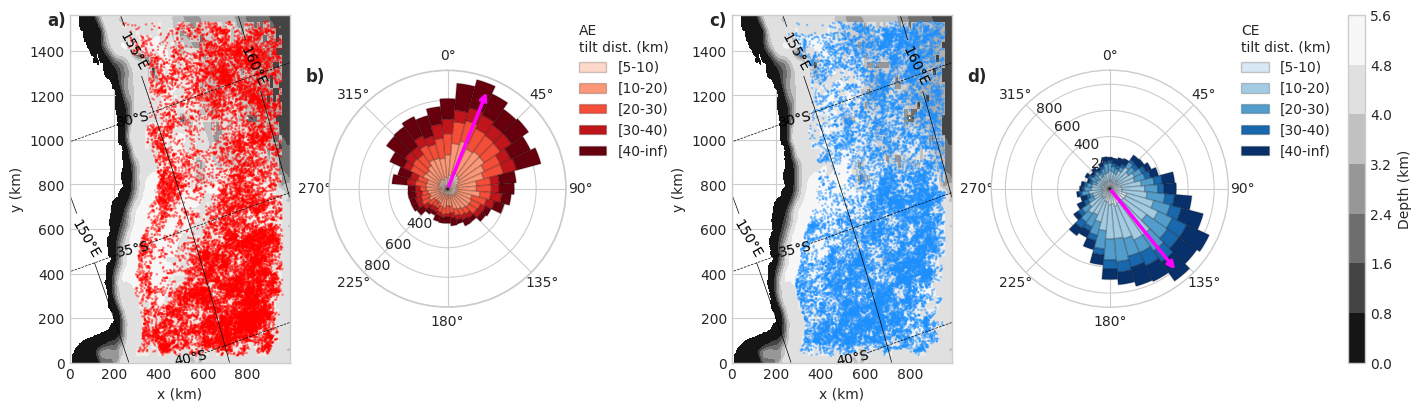

Ro 0.2–0.4: n=47346
AE mean tilt dir 17, tilt dis 28 km
CE mean tilt dir 144, tilt dis 23 km


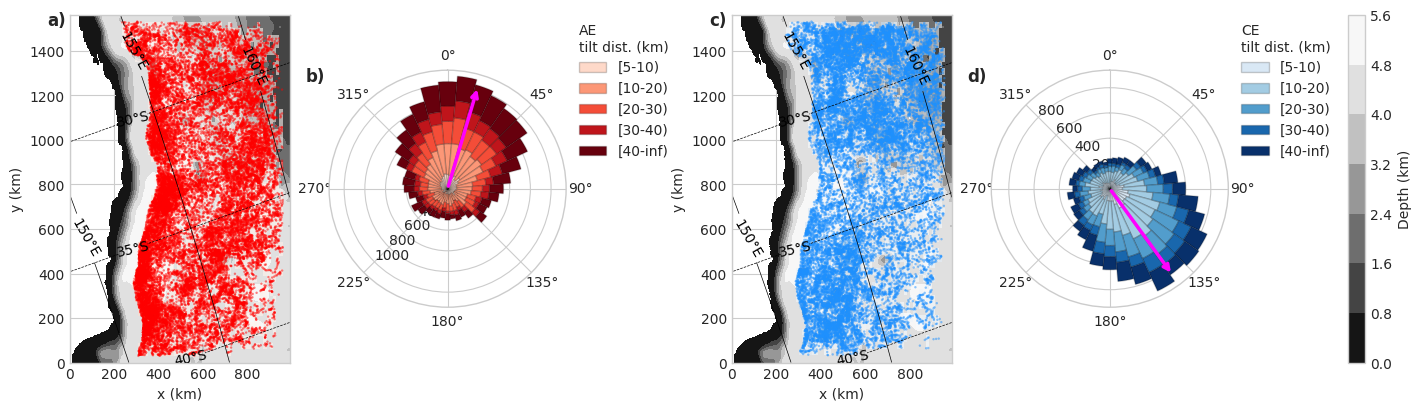

Ro 0.4–0.6: n=13922
AE mean tilt dir -4, tilt dis 22 km
CE mean tilt dir 157, tilt dis 22 km


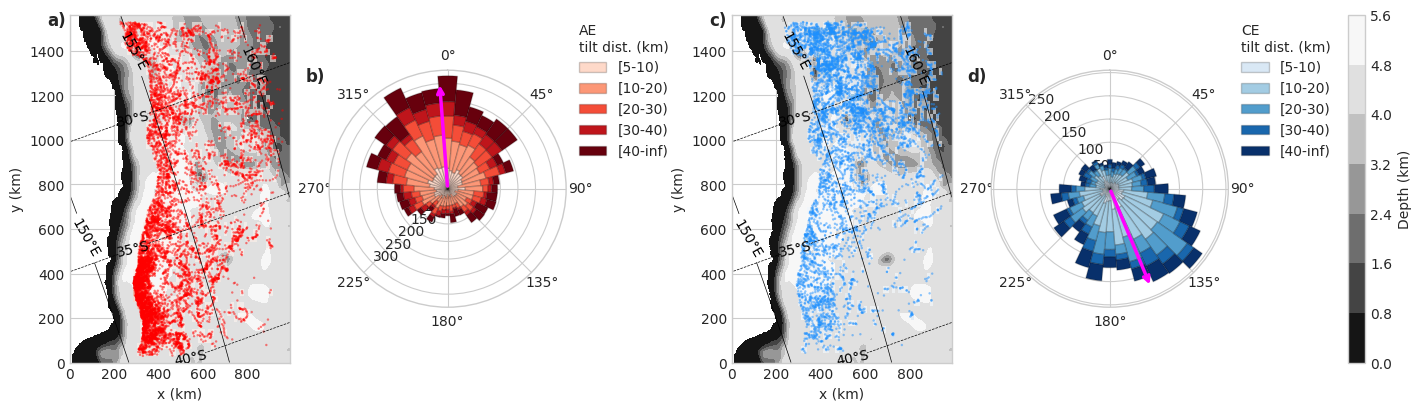

Ro 0.6–0.8: n=2327
AE mean tilt dir -27, tilt dis 21 km
CE mean tilt dir 166, tilt dis 21 km


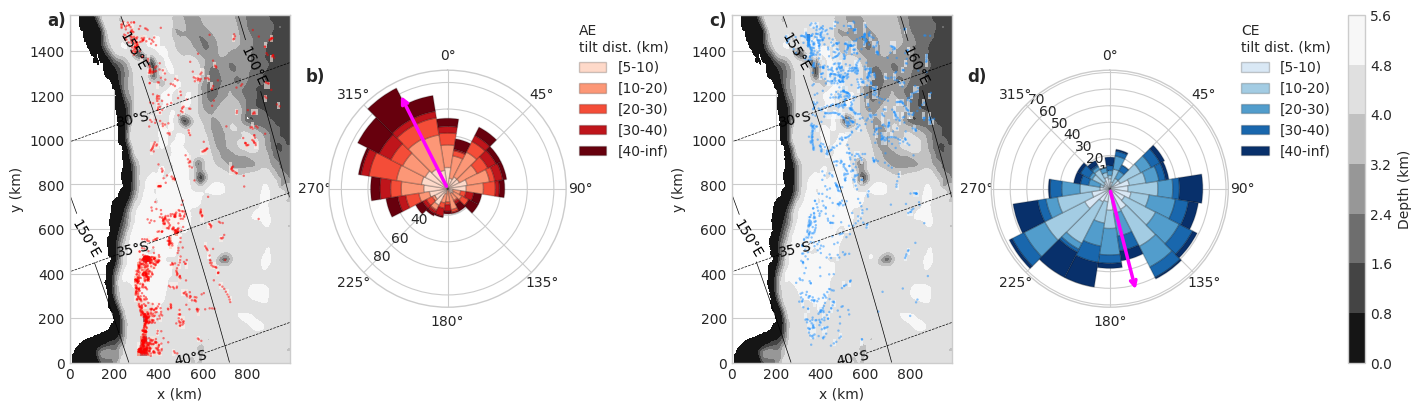

Ro 0.8–1.0: n=420
AE mean tilt dir -118, tilt dis 23 km
CE mean tilt dir 169, tilt dis 24 km


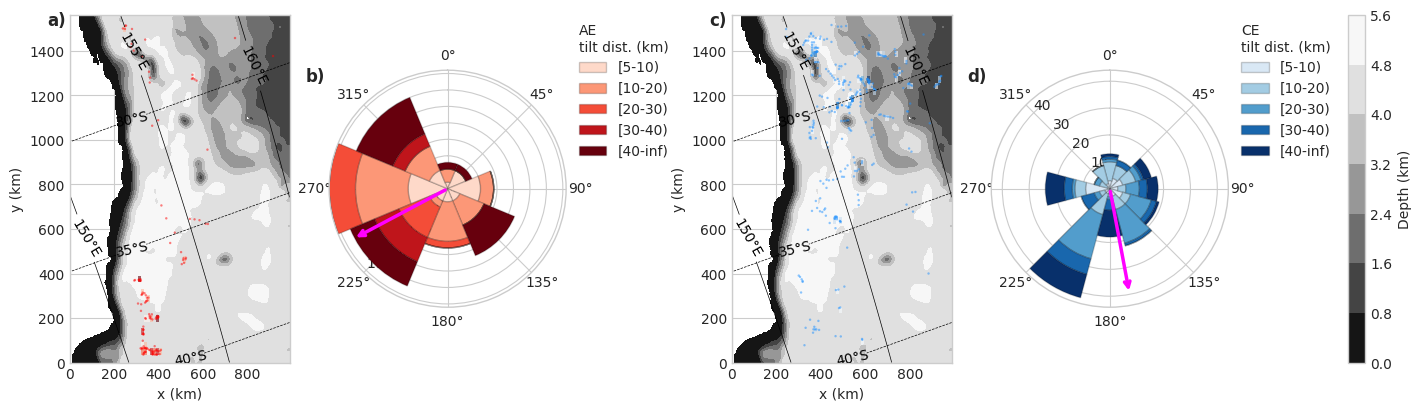

Ro 1.0–1.2: n=86
AE mean tilt dir -90, tilt dis 28 km
CE mean tilt dir 174, tilt dis 26 km


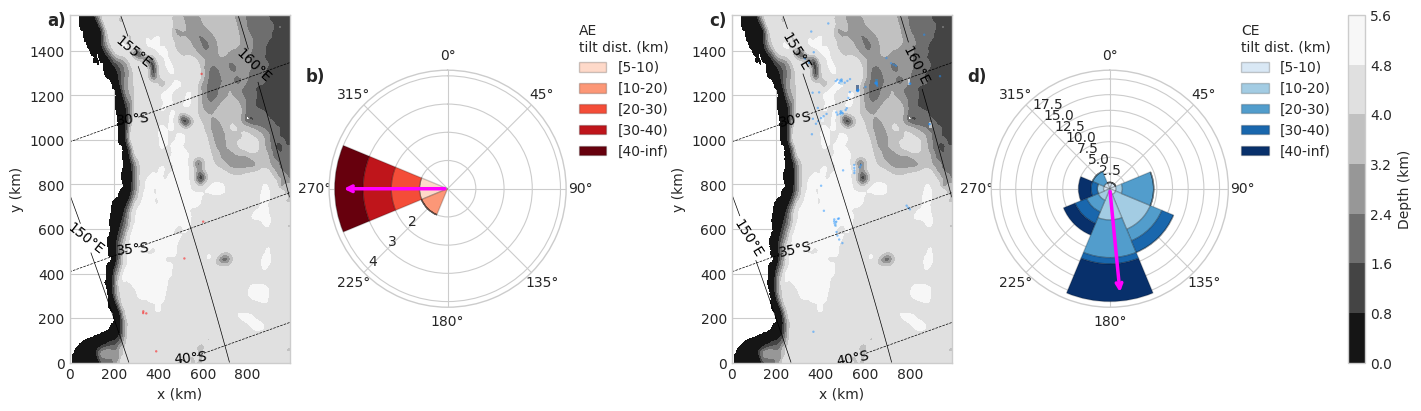

In [208]:
ro_bins=np.arange(0,1.2+.2,.2)

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    df=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['U1','U2','D1','D2']))].copy()
    print(f'Ro {lo:.1f}–{hi:.1f}: n={len(df)}')
    fig,axs=plot_tilt_summary(df)

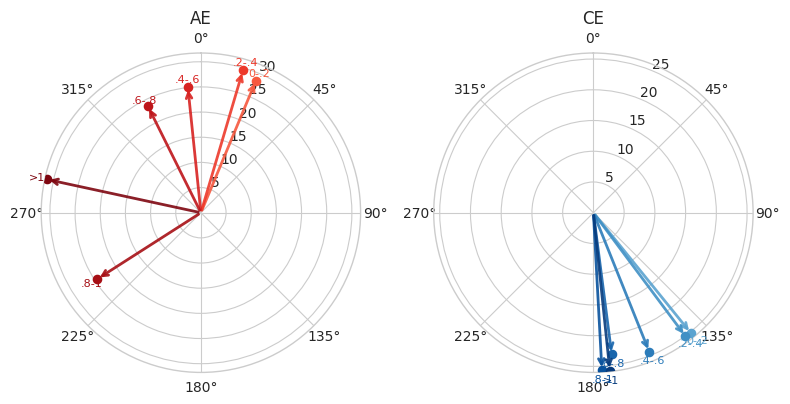

In [67]:
ro_bins=[0,.2,.4,.6,.8,1,np.inf]
labels=['0-.2','.2-.4','.4-.6','.6-.8','.8-1','>1']

vectors={'AE':{'theta':[],'r':[]},'CE':{'theta':[],'r':[]}}

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    d=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['U1','U2','D1','D2']))&(df_eddies.TiltDis>=5)].copy()

    for cyc in ['AE','CE']:
        sub=d[d.Cyc.eq(cyc)].dropna(subset=['TiltDir','TiltDis'])
        theta=np.deg2rad(sub.TiltDir)
        theta_mean=np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi)
        vectors[cyc]['theta'].append(theta_mean)
        vectors[cyc]['r'].append(sub.TiltDis.mean())

fig,axs=plt.subplots(1,2,figsize=(8,4),subplot_kw={'projection':'polar'})

for ax,cyc,cmap in zip(axs,['AE','CE'],['Reds','Blues']):
    theta=np.array(vectors[cyc]['theta']); r=np.array(vectors[cyc]['r'])
    colors=getattr(plt.cm,cmap)(np.linspace(.55,.95,len(labels)))
    ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)

    for th,rr,label,color in zip(theta,r,labels,colors):
        ax.annotate('',xy=(th,rr),xytext=(0,0),
                    arrowprops=dict(arrowstyle='->',color=color,lw=2,alpha=.9))
        ax.scatter(th,rr,color=color,s=35,zorder=3)
        ax.text(th,rr*1.06,label,ha='center',va='center',fontsize=8,color=color)

    ax.set_title(cyc)

plt.tight_layout()

#### Shear

In [213]:
sx = 'clim_upper_minus_deep_east_ms'
sy = 'clim_upper_minus_deep_north_ms'

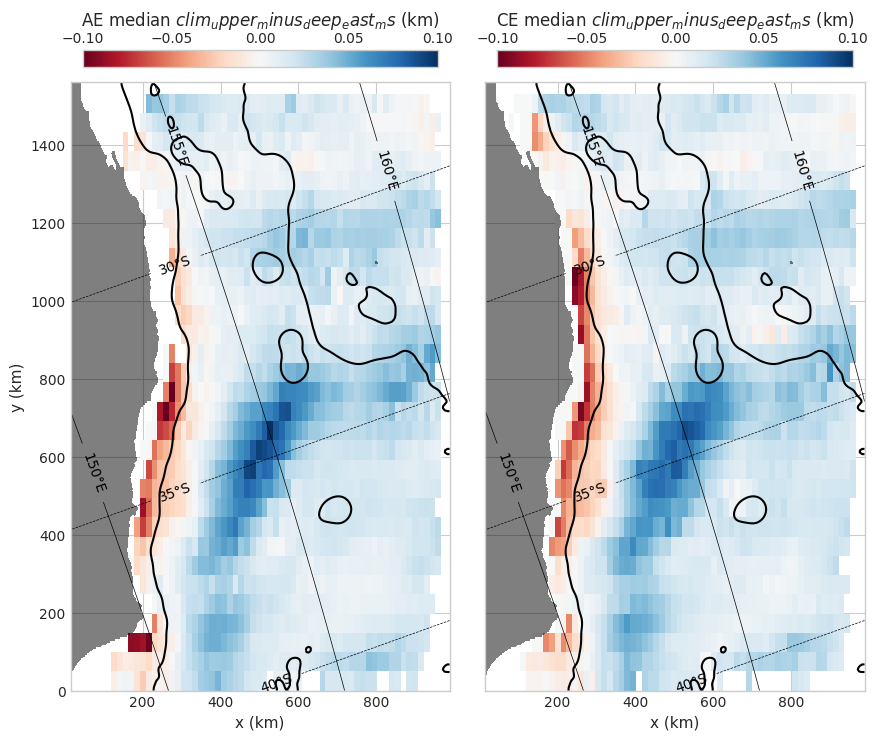

In [234]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric=sx, vmin=-.1, vmax=.1, cmaps={'AE': 'RdBu', 'CE': 'RdBu'})

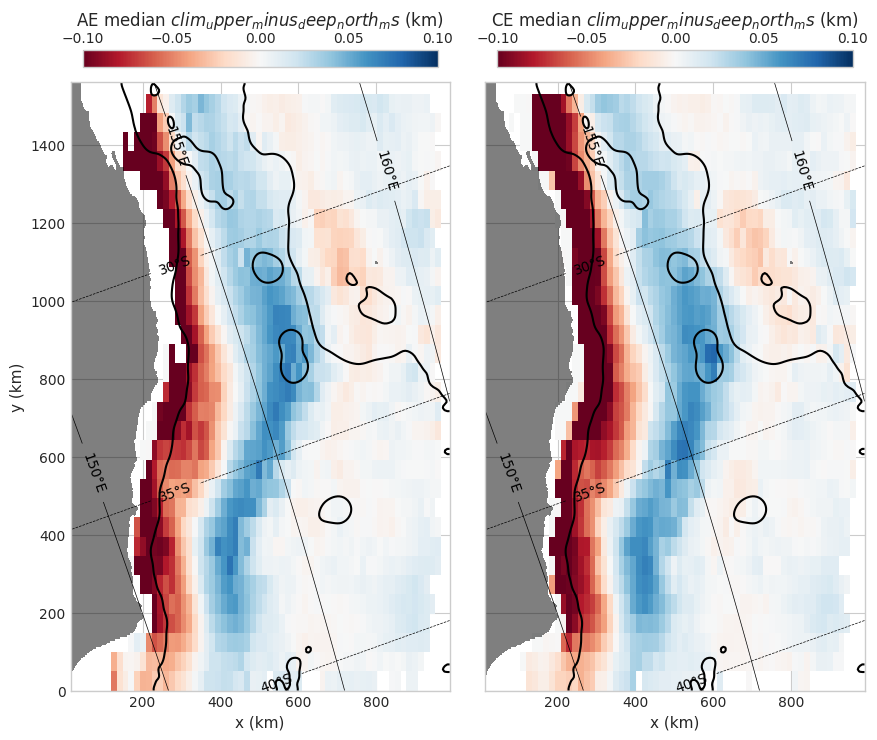

In [240]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric=sy, vmin=-.1, vmax=.1, cmaps={'AE': 'RdBu', 'CE': 'RdBu'})

In [247]:
df_eddies.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'h', 'f', 'beta', 'dhdx', 'dhdy',
       'zeta_mean', 'abs_vort', 'PV', 'PV_footprint_n',
       'PV_weight_effective_n', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_plan_mean_local_mag', 'PV_grad_plan_rms_local_mag',
       'PV_grad_plan_p90_local_mag', 'PV_grad_plan_coherence',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_topo_mean_local_mag',
       'PV_grad_topo_rms_local_mag', 'PV_grad_topo_p90_local_mag',
       'PV_grad_topo_coherence', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_mean_local_mag', 'PV_grad_rms_local_mag',
       'PV_grad_p90_local_mag', 'PV_grad_coherence', 'PV_grad_eddy_x',
       'PV_grad_eddy_y', 'PV_grad_eddy_mean_local_mag',
       'PV_grad_eddy_rms_local_mag', 'PV_grad_eddy_p90_local_mag',
       'PV_grad_eddy_coherence', 'PV_grad_full_x', 'PV_grad_full_y',
   

<Axes: xlabel='clim_upper_minus_deep_east_ms', ylabel='Tilt distance (km)'>

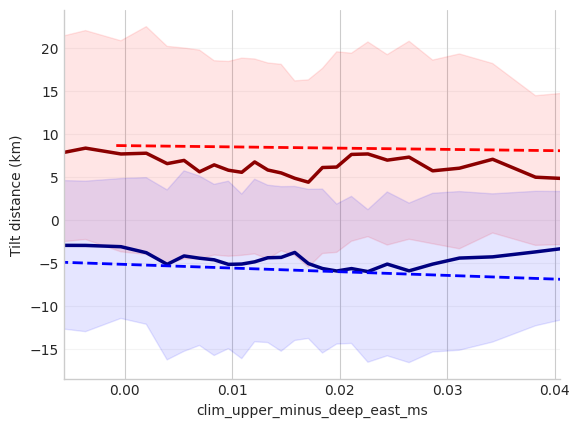

In [256]:
fig, ax = plt.subplots()
df_eddies['TiltDis_x'] = np.cos(np.deg2rad(df_eddies.TiltDir)) * df_eddies.TiltDis
df_eddies['TiltDis_y'] = np.sin(np.deg2rad(df_eddies.TiltDir)) * df_eddies.TiltDis
binned_tilt_panel(ax, df_eddies, sx, sx, ylabel="Tilt distance (km)", ycol='TiltDis_x', linfit=True)

<Axes: xlabel='clim_upper_minus_deep_east_ms', ylabel='Tilt distance (km)'>

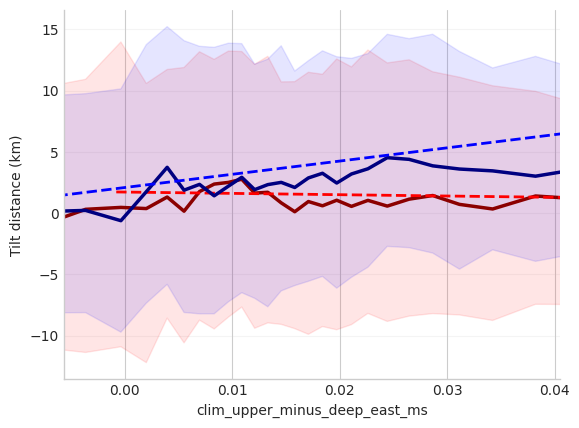

In [255]:
fig, ax = plt.subplots()
binned_tilt_panel(ax, df_eddies, sx, sx, ylabel="Tilt distance (km)", ycol='TiltDis_y', linfit=True)

<Axes: xlabel='clim_upper_minus_deep_north_ms', ylabel='Tilt distance (km)'>

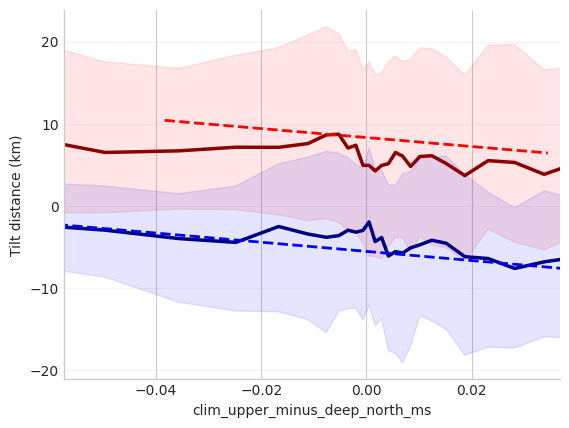

In [254]:
fig, ax = plt.subplots()
binned_tilt_panel(ax, df_eddies, sy, sy, ylabel="Tilt distance (km)", ycol='TiltDis_x', linfit=True)

<Axes: xlabel='clim_upper_minus_deep_north_ms', ylabel='Tilt distance (km)'>

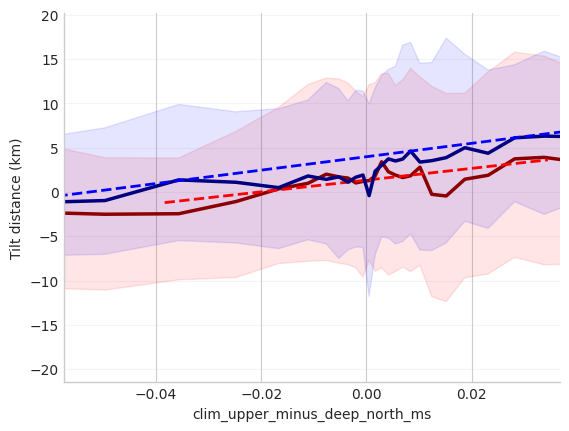

In [253]:
fig, ax = plt.subplots()
binned_tilt_panel(ax, df_eddies, sy, sy, ylabel="Tilt distance (km)", ycol='TiltDis_y', linfit=True)